In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
depth_values = [1,2,3,5,7,10]
datasets = ["bc",  "hp", "hpimp"]

df = pd.read_csv("./dt_metrics.csv")
df.head()

,dataset,hyperparam,value,kind,accuracy,precision,sensitivity,specificity,f1
0,bc,criterion,entropy,test,0.946903,1.00000,0.869565,1.000000,0.930233
1,bc,criterion,entropy,train,0.978070,1.00000,0.939759,1.000000,0.968944
2,bc,criterion,gini,test,0.938053,0.97561,0.869565,0.985075,0.919540
3,bc,criterion,gini,train,0.969298,1.00000,0.915663,1.000000,0.955975
4,bc,max_depth,10,test,0.964602,0.93750,0.978261,0.955224,0.957447


In [11]:
def get_dataset_name(dataset):
    if dataset == "bc":
        return "Breast Cancer"
    elif dataset == "hp":
        return "Hepatitis"
    else:
        return "Hepatitis (Imputed)"

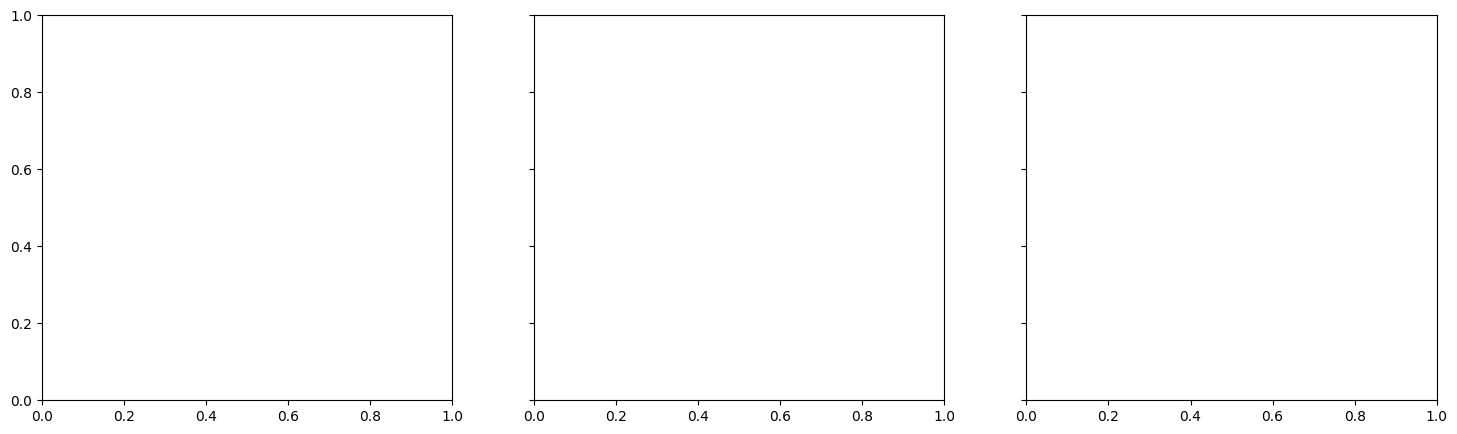

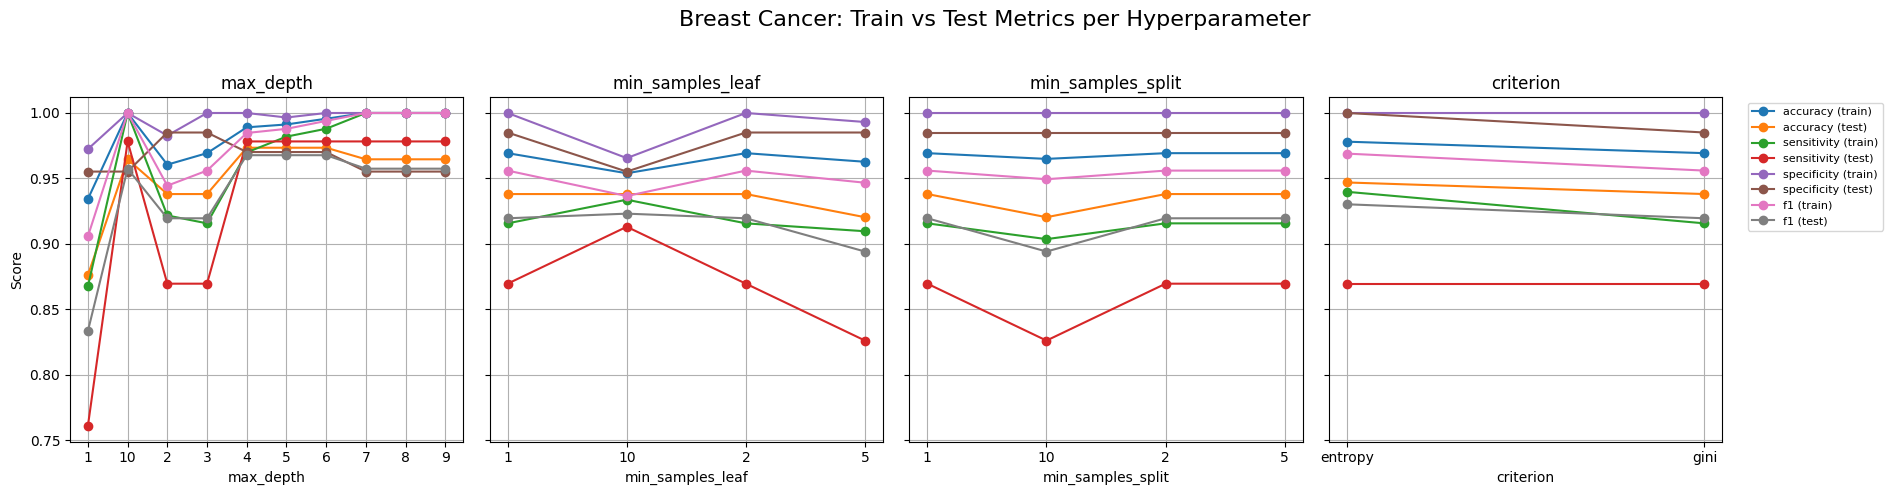

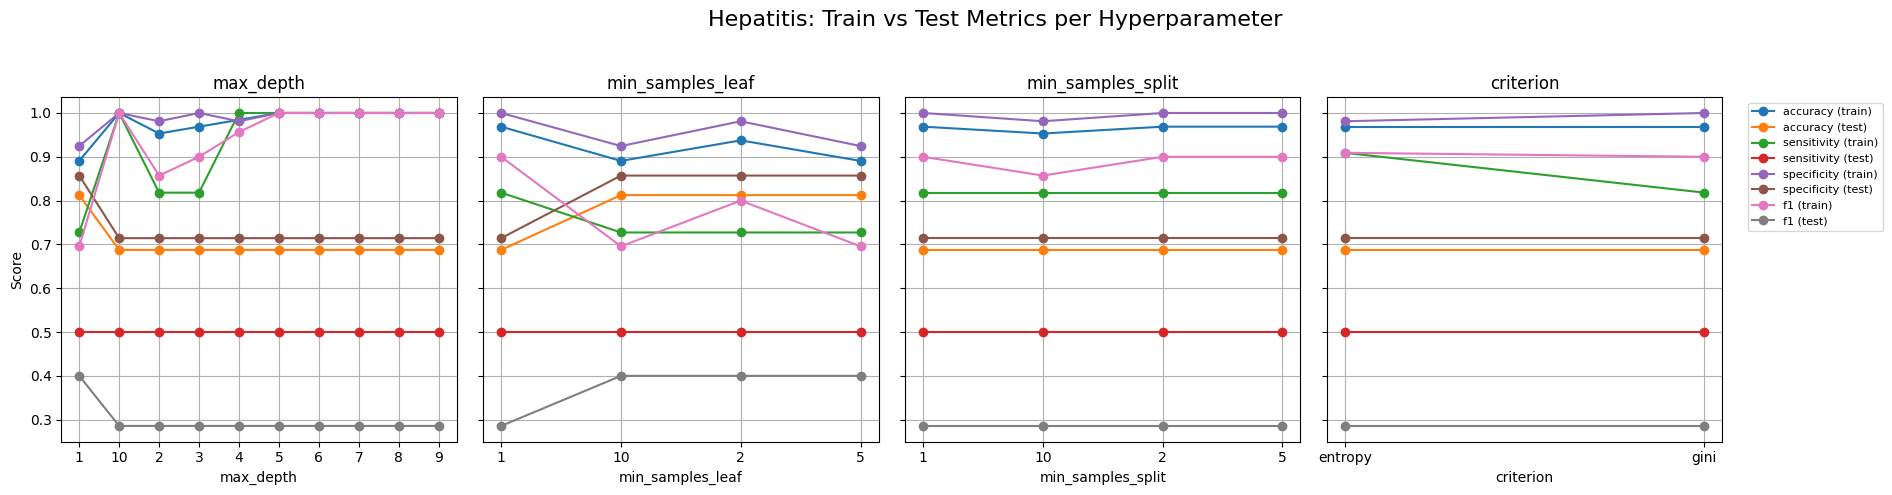

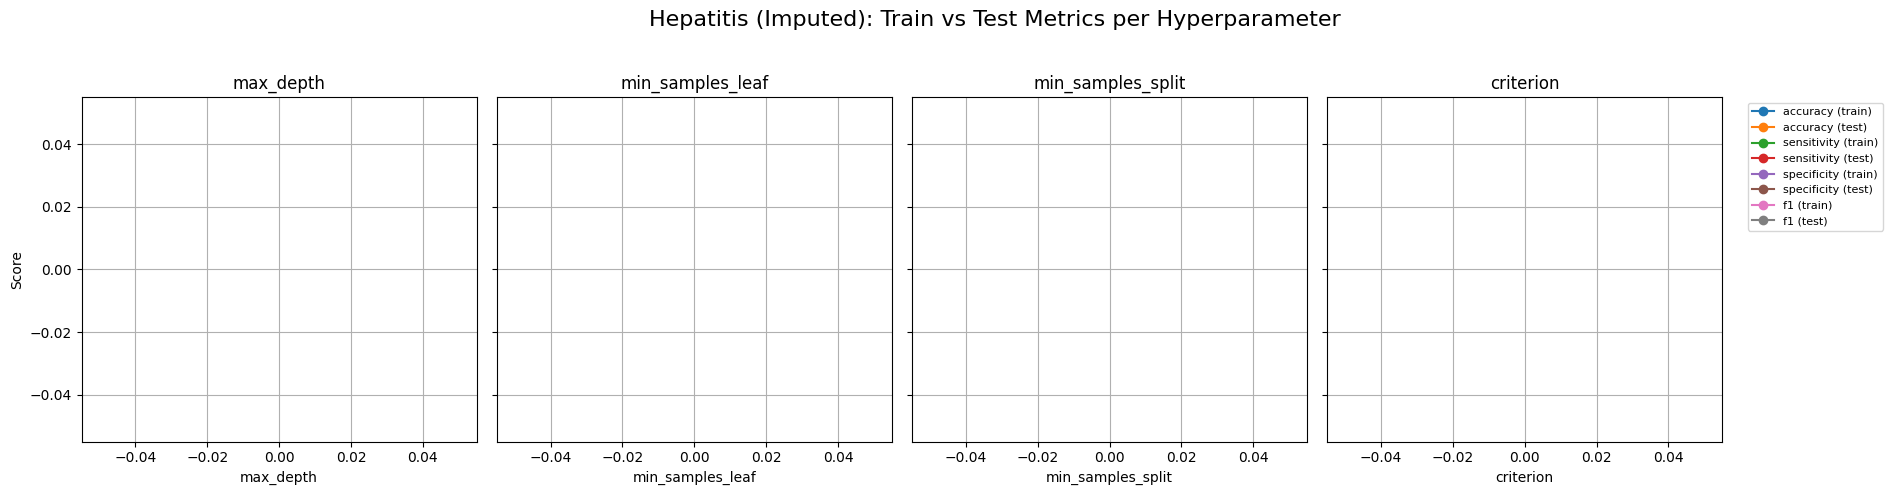

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

metrics = ["accuracy", "sensitivity", "specificity", "f1"]
hyperparams = ["max_depth", "min_samples_leaf", "min_samples_split", "criterion"] 

for dataset in datasets:
    data = df[df["dataset"] == dataset]
    
    # Create one figure per dataset, subplots = number of hyperparameters
    fig, axes = plt.subplots(1, len(hyperparams), figsize=(20,5), sharey=True)
    fig.suptitle(f"{get_dataset_name(dataset)}: Train vs Test Metrics per Hyperparameter", fontsize=16)
    
    for j, hyper in enumerate(hyperparams):
        ax = axes[j]
        hyper_data = data[data["hyperparam"] == hyper]
        
        # Plot train/test for each metric
        for metric in metrics:
            for kind in ["train", "test"]:
                kind_data = hyper_data[hyper_data["kind"] == kind]
                
                # sort by hyperparameter value for consistent plotting
                kind_data = kind_data.sort_values("value")
                
                ax.plot(kind_data["value"], kind_data[metric], marker="o", 
                        label=f"{metric} ({kind})")
        
        ax.set_xlabel(hyper)
        ax.set_title(f"{hyper}")
        ax.grid(True)
        if j == len(hyperparams)-1:
            ax.legend(fontsize=8, bbox_to_anchor=(1.05,1), loc='upper left')
        if j == 0:
            ax.set_ylabel("Score")
    
    plt.tight_layout(rect=(0,0,0.95,0.95))
    plt.show()

